# Sample 4 — Multi-head attention

`sample-3` computed attention once, with one set of `W_Q`/`W_K`/`W_V` matrices. That gives the
model exactly one "lens" for deciding what's relevant. **Multi-head attention** runs several
smaller attention computations in parallel, each with its own weights, so the model can learn
several different notions of relevance at once (e.g. one head tracking nearby words, another
tracking subject-verb agreement) — then combines the results.

**Goals**
1. Split `d_model` into `num_heads` smaller pieces and run attention independently per head, in
   NumPy, so the reshape/split/concat mechanics stay visible.
2. Re-implement the same computation in PyTorch and confirm it matches — the bridge into
   `sample-5`, where everything moves to PyTorch for good.


## 1. Setup

A slightly bigger example than `sample-3` — 6 tokens, `d_model = 8` — split across `num_heads =
2` heads, so each head works with `d_k = 4` dimensions.

In [1]:
import numpy as np

rng = np.random.default_rng(seed=0)

words = ["the", "cat", "sat", "on", "the", "mat"]
seq_len, d_model = len(words), 8
num_heads = 2
d_k = d_model // num_heads
print(f"seq_len={seq_len}, d_model={d_model}, num_heads={num_heads}, d_k={d_k}")

X = rng.normal(scale=0.5, size=(seq_len, d_model))


seq_len=6, d_model=8, num_heads=2, d_k=4


## 2. Project, then split into heads

We still compute one `Q`, `K`, `V` for the whole `d_model` width using one weight matrix each
(`(d_model, d_model)`) — that's more efficient than having `num_heads` separate small weight
matrices, and mathematically equivalent to slicing each weight matrix into `num_heads` column
blocks.

The split into heads is just a `reshape`: view the last dimension `d_model` as
`(num_heads, d_k)`, then move the head axis in front of the sequence axis so each head's slice is
a clean `(seq_len, d_k)` matrix.

In [2]:
W_Q = rng.normal(scale=0.3, size=(d_model, d_model))
W_K = rng.normal(scale=0.3, size=(d_model, d_model))
W_V = rng.normal(scale=0.3, size=(d_model, d_model))
W_O = rng.normal(scale=0.3, size=(d_model, d_model))  # output projection, applied after concat

Q, K, V = X @ W_Q, X @ W_K, X @ W_V
print("Q, K, V shape before split:", Q.shape)

def split_heads(x, num_heads, d_k):
    seq_len = x.shape[0]
    # (seq_len, d_model) -> (seq_len, num_heads, d_k) -> (num_heads, seq_len, d_k)
    return x.reshape(seq_len, num_heads, d_k).transpose(1, 0, 2)

Q_heads = split_heads(Q, num_heads, d_k)
K_heads = split_heads(K, num_heads, d_k)
V_heads = split_heads(V, num_heads, d_k)
print("Q_heads shape after split:", Q_heads.shape, " (num_heads, seq_len, d_k)")


Q, K, V shape before split: (6, 8)
Q_heads shape after split: (2, 6, 4)  (num_heads, seq_len, d_k)


## 3. Attention, independently per head

Same `softmax(QK^T / sqrt(d_k)) V` as `sample-3`, run once per head with that head's own
`d_k`-sized slice of `Q`, `K`, `V`.

In [3]:
def softmax(x, axis=-1):
    shifted = x - np.max(x, axis=axis, keepdims=True)
    exp = np.exp(shifted)
    return exp / np.sum(exp, axis=axis, keepdims=True)

head_outputs = []
head_weights = []
for h in range(num_heads):
    scores = Q_heads[h] @ K_heads[h].T / np.sqrt(d_k)
    weights = softmax(scores, axis=-1)
    out = weights @ V_heads[h]
    head_outputs.append(out)
    head_weights.append(weights)
    print(f"head {h}: scores {scores.shape}, output {out.shape}")


head 0: scores (6, 6), output (6, 4)
head 1: scores (6, 6), output (6, 4)


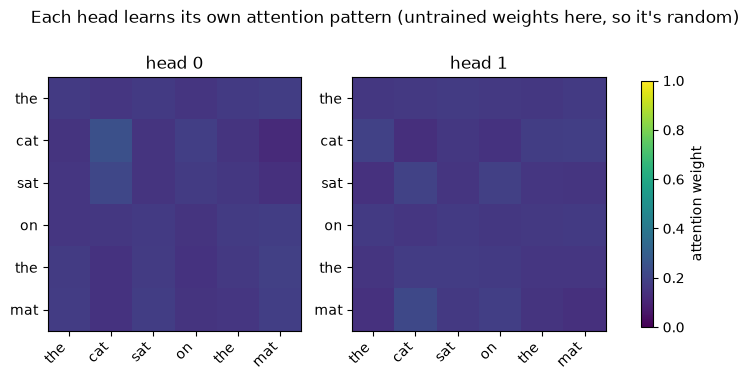

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, num_heads, figsize=(4.5 * num_heads, 4))
for h, ax in enumerate(axes):
    im = ax.imshow(head_weights[h], cmap="viridis", vmin=0, vmax=1)
    ax.set_xticks(range(seq_len)); ax.set_xticklabels(words, rotation=45, ha="right")
    ax.set_yticks(range(seq_len)); ax.set_yticklabels(words)
    ax.set_title(f"head {h}")
fig.colorbar(im, ax=axes, label="attention weight", shrink=0.8)
plt.suptitle("Each head learns its own attention pattern (untrained weights here, so it's random)")
plt.show()


Untrained, these two heads' patterns are just noise — but note they're *different* noise. Once
trained, heads like this specialize: this is the mechanism that lets the model track several
kinds of relationships between tokens at once, not the training itself.

## 4. Concatenate heads, project back down

Reverse the split: move the head axis back after the sequence axis and flatten `(num_heads,
d_k)` back into `d_model`. Then apply one more learned projection, `W_O`, so the heads' outputs
can mix before leaving the layer.

In [5]:
def combine_heads(head_outputs):
    # list of (seq_len, d_k) -> (num_heads, seq_len, d_k) -> (seq_len, num_heads, d_k) -> (seq_len, d_model)
    stacked = np.stack(head_outputs, axis=0).transpose(1, 0, 2)
    seq_len, num_heads, d_k = stacked.shape
    return stacked.reshape(seq_len, num_heads * d_k)

concat = combine_heads(head_outputs)
print("concatenated heads shape:", concat.shape, " (back to seq_len, d_model)")

mha_output = concat @ W_O
print("multi-head attention output shape:", mha_output.shape)
mha_output.round(3)


concatenated heads shape: (6, 8)  (back to seq_len, d_model)
multi-head attention output shape: (6, 8)


array([[ 0.199, -0.083,  0.361,  0.02 ,  0.252, -0.041,  0.107,  0.335],
       [ 0.224, -0.056,  0.434,  0.091,  0.236,  0.005,  0.001,  0.269],
       [ 0.17 , -0.07 ,  0.298,  0.015,  0.243,  0.023, -0.052,  0.232],
       [ 0.206, -0.082,  0.377,  0.028,  0.252, -0.041,  0.108,  0.34 ],
       [ 0.188, -0.085,  0.332,  0.002,  0.255, -0.04 ,  0.107,  0.333],
       [ 0.161, -0.083,  0.264, -0.033,  0.248, -0.021,  0.062,  0.303]])

## 5. Same computation, in PyTorch

Real transformer code doesn't use Python `for` loops over heads — it does the split with a single
batched `reshape`/`permute` and computes all heads at once with batched matrix multiplication.
Let's redo the exact same numbers in PyTorch and confirm they match the NumPy result.

In [6]:
import torch

X_t = torch.from_numpy(X)
W_Q_t, W_K_t, W_V_t, W_O_t = (torch.from_numpy(w) for w in (W_Q, W_K, W_V, W_O))

Q_t, K_t, V_t = X_t @ W_Q_t, X_t @ W_K_t, X_t @ W_V_t

# (seq_len, d_model) -> (seq_len, num_heads, d_k) -> (num_heads, seq_len, d_k)
def split_heads_torch(x):
    return x.view(seq_len, num_heads, d_k).permute(1, 0, 2)

Q_h, K_h, V_h = split_heads_torch(Q_t), split_heads_torch(K_t), split_heads_torch(V_t)

# batched matmul: (num_heads, seq_len, d_k) @ (num_heads, d_k, seq_len) -> (num_heads, seq_len, seq_len)
scores_t = Q_h @ K_h.transpose(-2, -1) / (d_k ** 0.5)
weights_t = torch.softmax(scores_t, dim=-1)
out_t = weights_t @ V_h  # (num_heads, seq_len, d_k)

# (num_heads, seq_len, d_k) -> (seq_len, num_heads, d_k) -> (seq_len, d_model)
concat_t = out_t.permute(1, 0, 2).reshape(seq_len, d_model)
mha_output_t = concat_t @ W_O_t

max_abs_diff = (mha_output_t.numpy() - mha_output).__abs__().max()
print("PyTorch output matches NumPy output:", np.allclose(mha_output_t.numpy(), mha_output))
print("max abs difference:", max_abs_diff)


PyTorch output matches NumPy output: True
max abs difference: 1.1102230246251565e-16


Identical numbers, produced with `torch.Tensor` operations instead of `np.ndarray` ones — same
matrix multiplications, just batched over heads instead of looped in Python. From here on, we
build directly on PyTorch, since `sample-6` needs autograd to train.

**Next:** `sample-5-transformer-block` wraps this multi-head attention in the rest of a
transformer block: residual connections, layer normalization, and a feed-forward network.